In [1]:
import numpy as np
from env.charging_env import ChargingStationEnv
from policy.queue.fifo import FIFOQueuePolicy

env = ChargingStationEnv(
    n_piles=2,
    n_nozzles=1,
    n_bricks=5,
    p_brick=25,
    queue_capacity=10,
    lam=5.0,
)

obs, info = env.reset(seed=42)
done = False
rng = np.random.default_rng(1)
policy = FIFOQueuePolicy()
total_reward = 0.0

while not done:
    mask = env.action_masks()
    action = policy.select_pile(obs, mask, rng)
    obs, reward, done, _, info = env.step(action)
    total_reward += reward

print(f"Finished EVs: {len(env.engine.metrics.finished_evs)}")
print(f"Dropped EVs: {len(env.engine.metrics.dropped_evs)}")
print(f"Avg L: {env.engine.metrics.average_L():.3f}")
print(f"Avg Q: {env.engine.metrics.average_Q():.3f}")
print(f"Total reward: {total_reward:.3f}")
print(f"Sim time: {env.engine.current_time:.1f}")


Finished EVs: 65
Dropped EVs: 225
Avg L: 11.367
Avg Q: 9.392
Total reward: -24773.789
Sim time: 1440.0


In [ ]:
env.engine.metrics.pile

In [ ]:
EVs = env.engine.metrics.arrived_evs
# for ev in EVs:
#     print(ev.arrival_time)

np.float64(62.47745103887757)

In [ ]:
import pandas as pd

frames = []
for ev in env.engine.metrics.finished_evs:
    if not ev.charge_trace:
        continue
    d = pd.DataFrame(
        ev.charge_trace,
        columns=["t", "S", "p_BMS", "p_act", "p_allot"],
    )
    d.insert(0, "ev_id", ev.id)
    d.insert(2, "C_b", ev.c_b / 60)
    d.insert(3, "C_b", ev.c_b / 60)
    d.insert(4, "p_m", ev.p_req_max)
    frames.append(d)

df_all = pd.concat(frames, ignore_index=True).round(2)

In [24]:
id = 0
df_all[df_all['ev_id'].eq(id)]

,ev_id,t,C_b,S,p_m,p_BMS,p_act,p_allot
0,0,12.02,150.0,0.19,150.0,150.0,125.0,125.0
1,0,50.84,150.0,0.72,150.0,105.0,105.0,125.0
2,0,62.48,150.0,0.82,150.0,66.3,105.0,125.0


In [ ]:
# (time, SoC, BMS request, actual power, allotment)
EVs[0].charge_trace

[(12.021043019829973, 0.18563397270177467, 150.0, 125.0, 125.0),
 (50.83987827677686,
  0.7199999999999999,
  105.00000000000006,
  105.00000000000006,
  125.0),
 (62.47745103887757,
  0.8232056498533479,
  66.29788130499455,
  105.00000000000006,
  125.0)]

Plotting EV 0 (pile 0, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 1 (pile 1, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 2 (pile 0, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=2
Plotting EV 3 (pile 1, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=2
Plotting EV 4 (pile 1, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=2


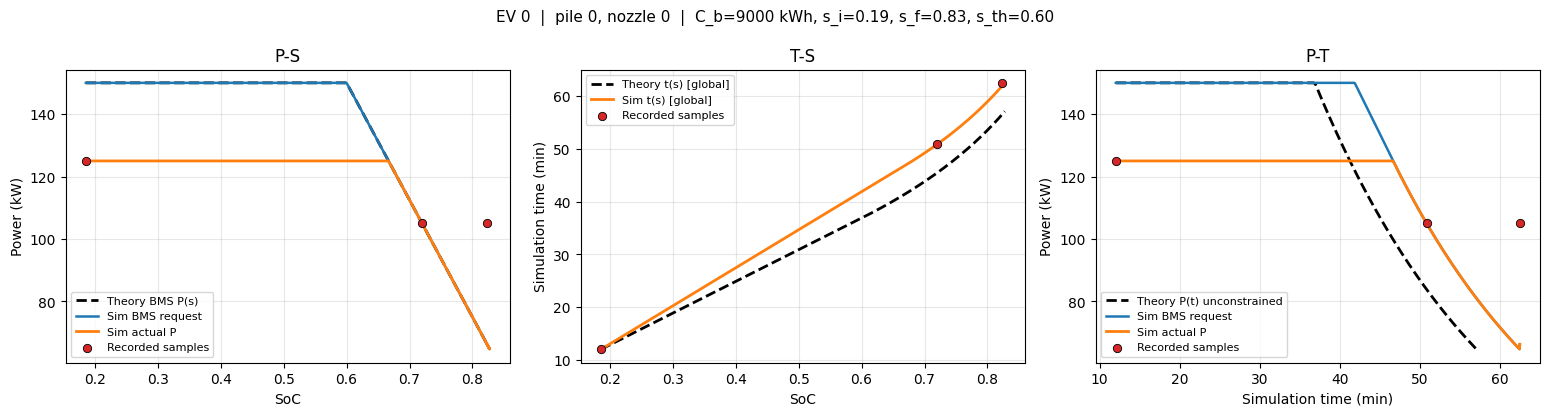

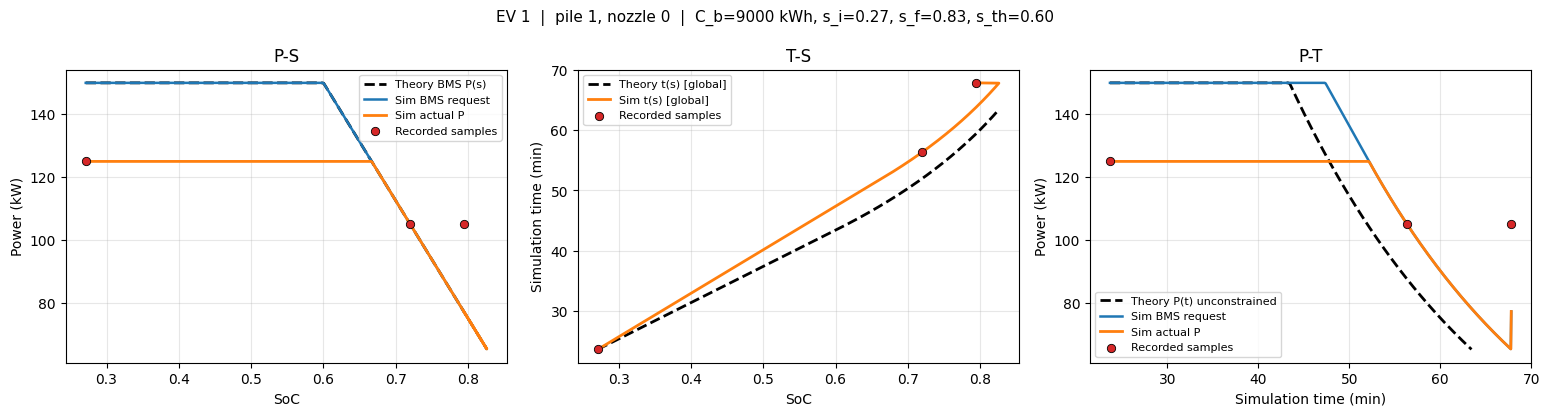

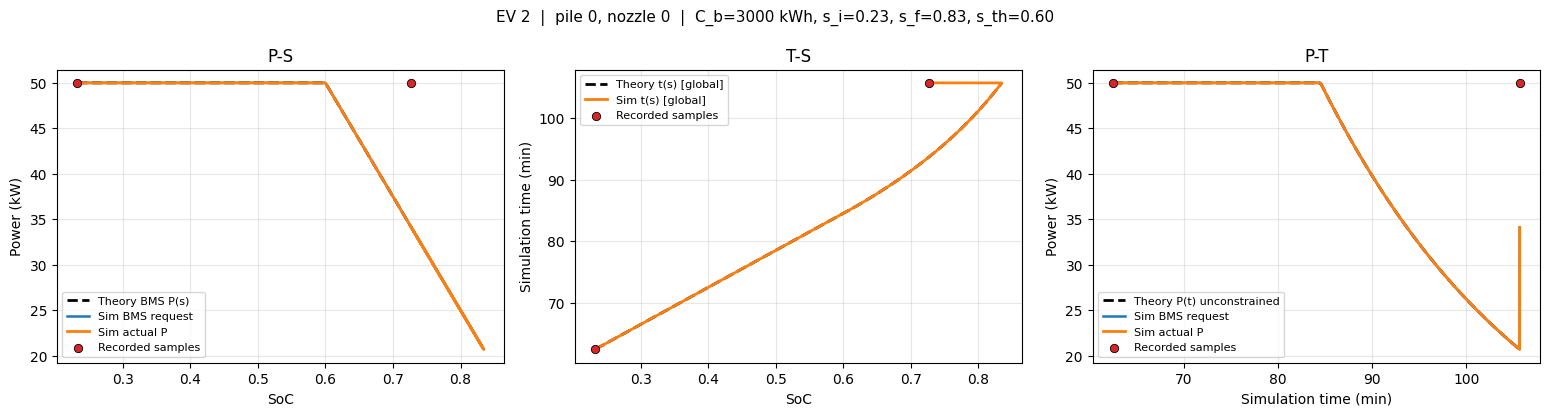

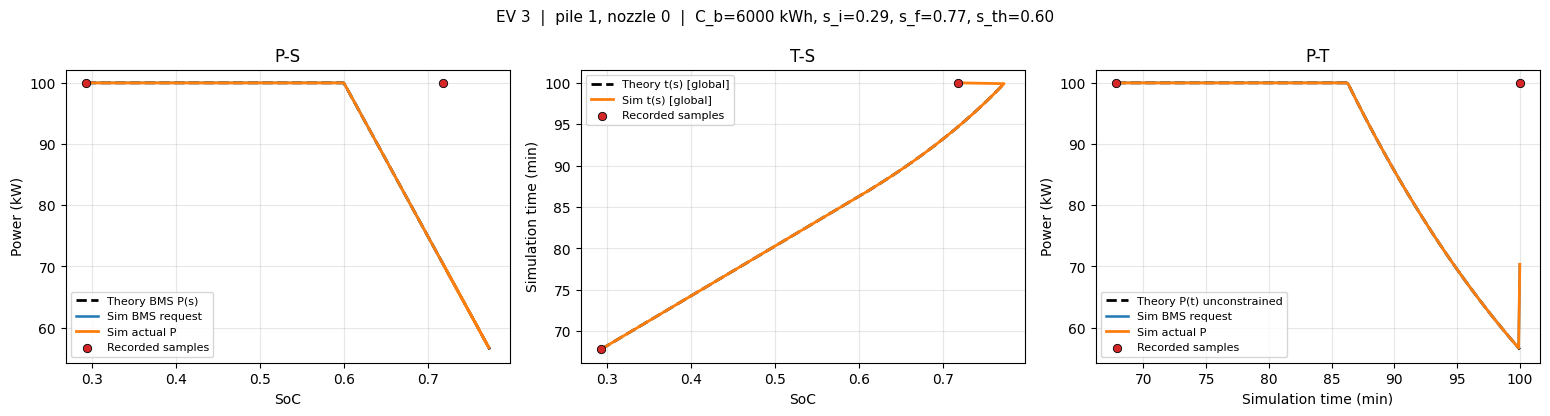

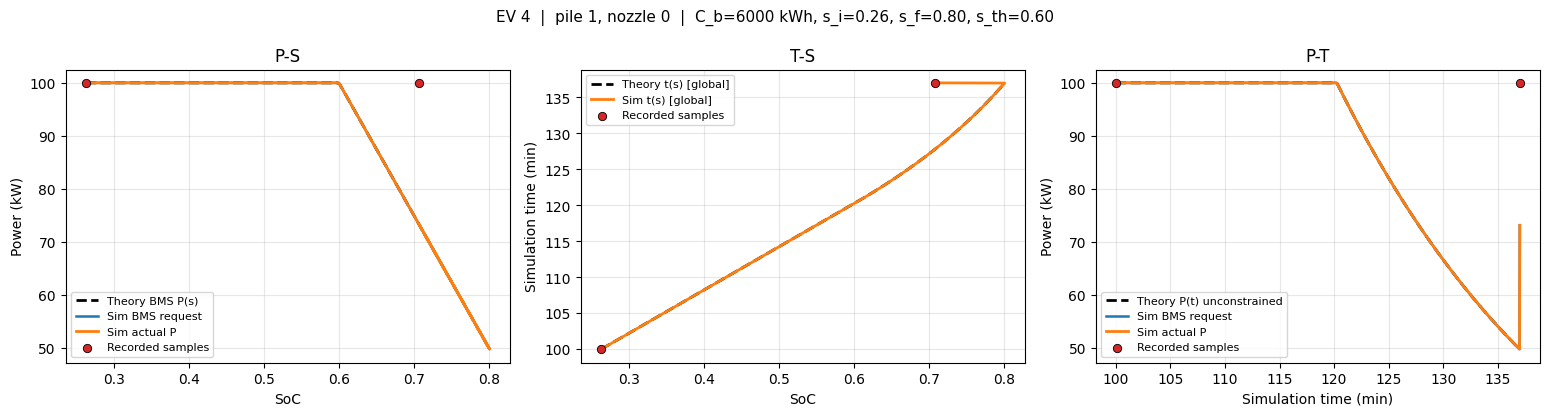

In [5]:
from visualization.ev_curves import plot_ev_theory_vs_sim
import matplotlib.pyplot as plt

figs = plot_ev_theory_vs_sim(
    env,
    ev_ids=[_ for _ in range(5)],
    charts=["P-S", "T-S", "P-T"],  # any subset of P-S, T-S, P-T
)
plt.show()
